# Fleet Health & Support Analysis

**The question:** for a fleet of deployed laptops and printers, what is driving support ticket volume, where is
it heading, and what should the support team do about it?

This notebook walks through the analysis end to end: a hidden hardware defect, seasonal demand, what actually
drives resolution time, a forecast with an honest backtest, and an automatic ticket classifier.

**A note on the data.** It is synthetic (3,000 devices, 5,505 tickets, Sep 2023 to Sep 14, 2026). The
seasonality, the battery defect and the severity effect were built into the generator
(`src/generate_data.py`), so the point of this notebook is to show the method recovers them, not to claim
these effects exist in any real fleet.

In [1]:
import subprocess, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.figsize": (9, 4), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
})
BLUE, ORANGE, GRAY = "#2a6fdb", "#e8702a", "#b8bec8"

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"
if not (DATA / "tickets.csv").exists():
    subprocess.run([sys.executable, str(ROOT / "src" / "generate_data.py")], check=True)

tickets = pd.read_csv(DATA / "tickets.csv", parse_dates=["ticket_date"])
devices = pd.read_csv(DATA / "devices.csv", parse_dates=["purchase_date", "warranty_end_date"])
print(f"{len(devices):,} devices, {len(tickets):,} tickets, {tickets.ticket_date.min().date()} to {tickets.ticket_date.max().date()}")

3,000 devices, 5,505 tickets, 2023-09-20 to 2026-09-14


## 1. The data

In [2]:
tickets.head()

,ticket_id,device_id,model,region,ticket_date,category,severity,description,resolution_hours,in_warranty
0,TCK-001815,DEV-01002,EliteBook 840,EMEA,2023-09-20,Network/Connectivity,Medium,Bluetooth peripherals fail to pair with the de...,8.1,True
1,TCK-004316,DEV-02342,Color LaserJet Enterprise M555,EMEA,2023-09-26,Hardware Failure,High,"Something is wrong with my device, urgent.",31.6,True
2,TCK-004358,DEV-02368,EliteBook 650,EMEA,2023-09-27,Print Quality,Low,Application suite freezes randomly during norm...,4.9,True
3,TCK-003273,DEV-01811,EliteBook 840,EMEA,2023-10-06,Software/OS,Medium,"OS fails to boot, stuck on repair screen after...",15.3,True
4,TCK-003086,DEV-01691,EliteBook 840,EMEA,2023-10-10,Hardware Failure,Medium,Unit overheats and shuts down under normal load.,9.7,True


In [3]:
print("Missing values:", int(tickets.isna().sum().sum() + devices.isna().sum().sum()))
print("Tickets per device (whole fleet): %.2f" % (len(tickets) / len(devices)))
print("Devices that never raised a ticket:", int((~devices.device_id.isin(tickets.device_id)).sum()))
print()
print(tickets.category.value_counts().to_string())

Missing values: 0
Tickets per device (whole fleet): 1.83
Devices that never raised a ticket: 762

category
Software/OS             1028
Network/Connectivity     960
Hardware Failure         904
Driver/Firmware          891
Print Quality            712
Battery                  602
Other                    408


## 2. Ticket volume and seasonality

Monthly volume climbs steadily because the fleet grows as devices are purchased. The data ends on Sep 14, so
September 2026 is a partial month; it is left out of every monthly analysis below, because it would look like a
demand drop that never happened.

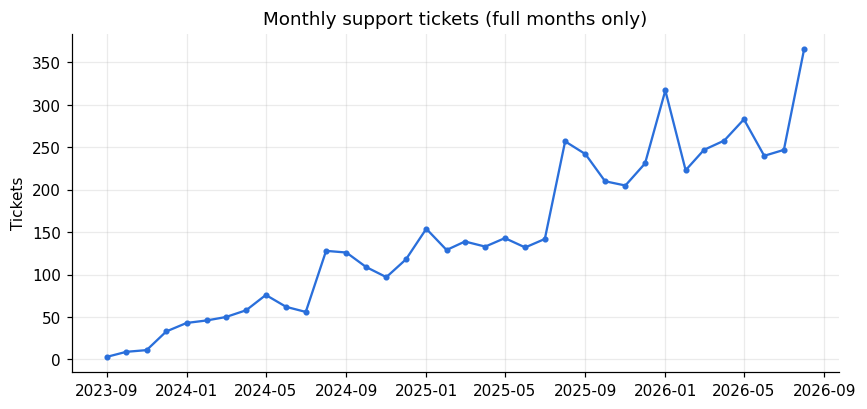

In [4]:
last_day = tickets.ticket_date.max()
monthly = tickets.set_index("ticket_date").resample("MS").size()
if last_day != last_day + pd.offsets.MonthEnd(0):
    monthly = monthly.iloc[:-1]

fig, ax = plt.subplots()
ax.plot(monthly.index, monthly.values, color=BLUE, marker="o", ms=3)
ax.set_title("Monthly support tickets (full months only)")
ax.set_ylabel("Tickets")
plt.show()

Raw totals are misleading for seasonality because of that growth trend: a January that is 27% above trend can
still look low next to a fast-growing autumn. So each month is divided by its trend (a centered 12-month moving
average) and the ratios are averaged by calendar month.

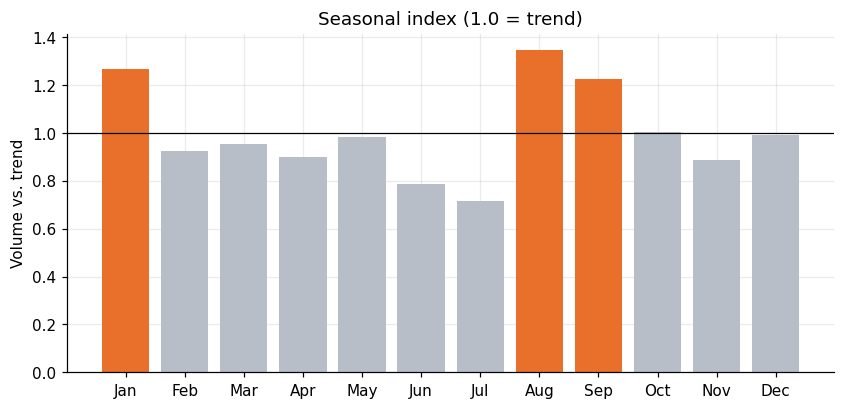

Aug 1.35x | Sep 1.22x | Jan 1.27x | Jun-Jul 0.75x


In [5]:
trend = monthly.rolling(12, center=True).mean().rolling(2).mean().shift(-1)
ratio = (monthly / trend).dropna()
season = ratio.groupby(ratio.index.month).mean()

fig, ax = plt.subplots()
labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
ax.bar(labels, season.values, color=[ORANGE if v > 1.2 else GRAY for v in season.values])
ax.axhline(1, color="black", lw=0.8)
ax.set_title("Seasonal index (1.0 = trend)")
ax.set_ylabel("Volume vs. trend")
plt.show()
print("Aug %.2fx | Sep %.2fx | Jan %.2fx | Jun-Jul %.2fx" % (season[8], season[9], season[1], season[[6, 7]].mean()))

**Takeaway:** demand peaks in August and September (back-to-school deployments) and again in January
(post-holiday return to office), with a summer lull in June and July. Staffing should follow that shape, not a
flat average.

## 3. The hidden defect: one purchase cohort

If a component batch is bad, its failures cluster by purchase date. So for the EliteBook 840, count battery
tickets per device, grouped by the quarter the device was bought. Dividing by devices in the cohort matters,
because older cohorts have had more time to accumulate tickets.

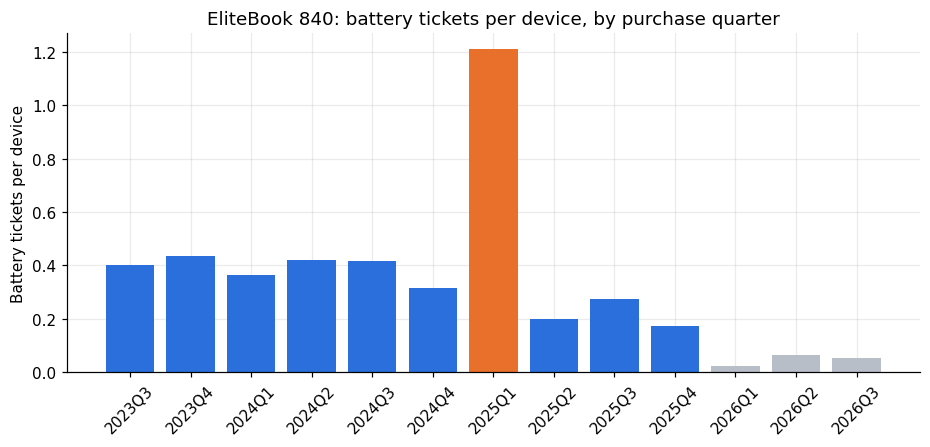

Q1 2025 cohort: 1.21 battery tickets/device
Other quarters through 2025: 0.17 to 0.44
vs. next-highest: 2.8x | vs. lowest: 7.0x


In [6]:
elite = devices[devices.model == "EliteBook 840"].copy()
elite["quarter"] = elite.purchase_date.dt.to_period("Q")
battery = tickets[(tickets.model == "EliteBook 840") & (tickets.category == "Battery")].merge(
    devices[["device_id", "purchase_date"]], on="device_id")
battery["quarter"] = battery.purchase_date.dt.to_period("Q")

cohort = pd.DataFrame({"devices": elite.groupby("quarter").size(),
                       "battery_tickets": battery.groupby("quarter").size()}).fillna(0)
cohort["per_device"] = cohort.battery_tickets / cohort.devices

fig, ax = plt.subplots(figsize=(10, 4))
colors = [ORANGE if str(q) == "2025Q1" else (GRAY if q > pd.Period("2025Q4") else BLUE) for q in cohort.index]
ax.bar([str(q) for q in cohort.index], cohort.per_device, color=colors)
ax.set_title("EliteBook 840: battery tickets per device, by purchase quarter")
ax.set_ylabel("Battery tickets per device")
plt.xticks(rotation=45)
plt.show()

mature = cohort[cohort.index <= pd.Period("2025Q4")]
others = mature.drop(pd.Period("2025Q1")).per_device
q1 = cohort.loc[pd.Period("2025Q1"), "per_device"]
print("Q1 2025 cohort: %.2f battery tickets/device" % q1)
print("Other quarters through 2025: %.2f to %.2f" % (others.min(), others.max()))
print("vs. next-highest: %.1fx | vs. lowest: %.1fx" % (q1 / others.max(), q1 / others.min()))

In [7]:
q1_tickets = battery[battery.quarter == pd.Period("2025Q1")].copy()
q1_tickets["days_after_purchase"] = (q1_tickets.ticket_date - q1_tickets.purchase_date).dt.days
in_window = q1_tickets.days_after_purchase.between(270, 420).sum()
print(f"{in_window} of {len(q1_tickets)} battery tickets from this cohort land 9-14 months after purchase")

41 of 46 battery tickets from this cohort land 9-14 months after purchase


**Takeaway:** a spike confined to one purchase window (grey bars are 2026 purchases, too new to have reached
the failure window) is the signature of a bad component batch. General wear-out would instead show a smooth
slope across cohorts. **Recommendation:** proactively contact this cohort for battery replacement before the
failures arrive.

## 4. What drives resolution time: severity, not category

Resolution time varies a lot. The question is whether ticket *type* or ticket *severity* explains it.

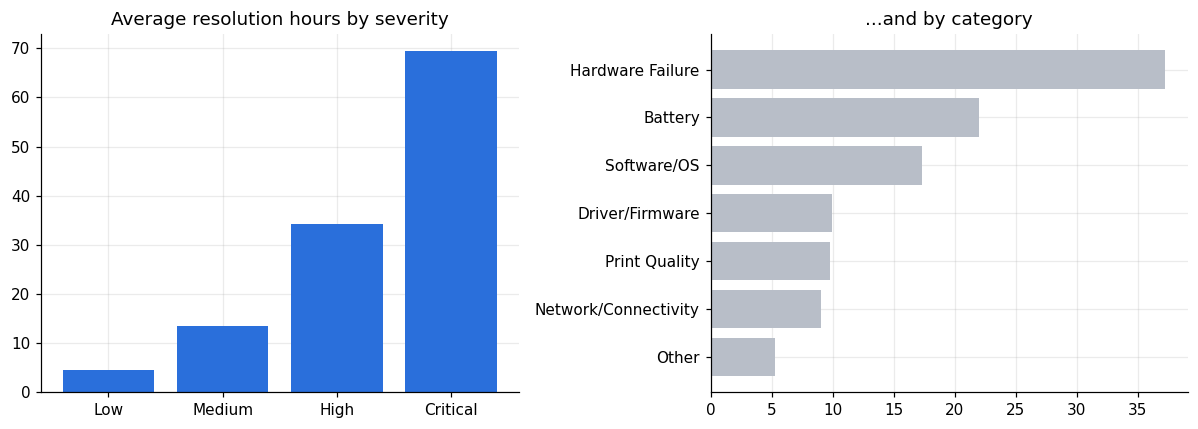

severity
Low          4.6
Medium      13.5
High        34.3
Critical    69.4


In [8]:
sev_order = ["Low", "Medium", "High", "Critical"]
by_sev = tickets.groupby("severity").resolution_hours.mean().reindex(sev_order)
by_cat = tickets.groupby("category").resolution_hours.mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(by_sev.index, by_sev.values, color=BLUE)
axes[0].set_title("Average resolution hours by severity")
axes[1].barh(by_cat.index, by_cat.values, color=GRAY)
axes[1].set_title("...and by category")
plt.tight_layout()
plt.show()
print(by_sev.round(1).to_string())

Category also looks like it matters (Hardware Failure is slow, Other is fast). But that could just be because
Hardware Failure tickets are mostly serious. The check: hold severity fixed and compare categories.

In [9]:
within = tickets.pivot_table(index="category", columns="severity", values="resolution_hours", aggfunc="mean")[sev_order]
print("Average resolution hours, category within severity:")
print(within.round(1).to_string())
print()
serious = tickets.assign(serious=tickets.severity.isin(["High", "Critical"])).groupby("category").serious.mean()
print("Share of tickets that are High or Critical, by category:")
print((serious * 100).round(0).astype(int).astype(str).add("%").to_string())

Average resolution hours, category within severity:
severity              Low  Medium  High  Critical
category                                         
Battery               4.7    13.5  35.7      59.7
Driver/Firmware       4.6    14.4  37.3      67.4
Hardware Failure      6.6    13.5  34.0      70.1
Network/Connectivity  4.6    12.7  32.6      44.6
Other                 4.5    12.6  41.8       NaN
Print Quality         4.8    13.5  34.3      76.5
Software/OS           4.5    13.7  33.7      80.3

Share of tickets that are High or Critical, by category:
category
Battery                 37%
Driver/Firmware          1%
Hardware Failure        74%
Network/Connectivity     1%
Other                    1%
Print Quality            2%
Software/OS             33%


**Takeaway:** within Low, Medium and High severity, resolution time is nearly identical across categories. The
category differences in the chart come from severity mix. Critical tickets vary more only because there are
few of them per category. **Recommendation:** set SLAs by severity, with a distinct fast-path for Critical
(about 69 hours today, versus 4.6 for Low).

## 5. Ticket rate by product and region

Ticket counts alone are misleading when models have different fleet sizes, so this normalizes by devices.

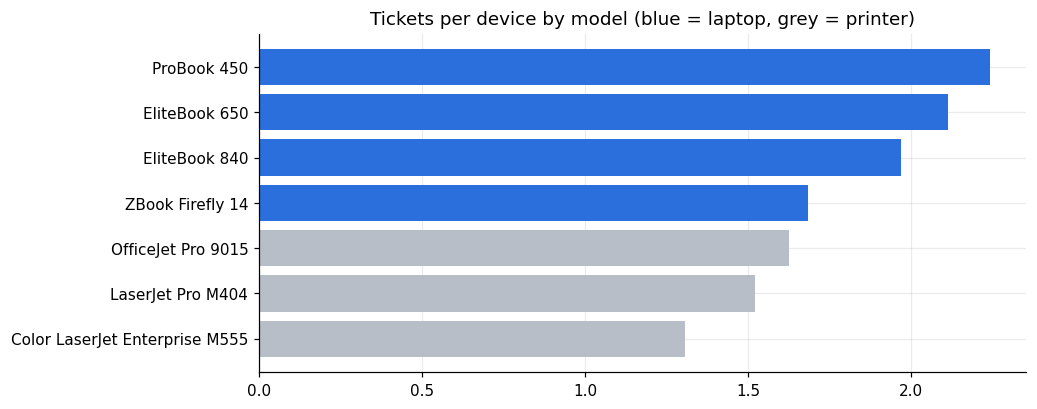

By type:   {'Laptop': 2.03, 'Printer': 1.49}
By region: {'APAC': 1.78, 'EMEA': 1.9, 'LATAM': 1.96, 'North America': 1.78}


In [10]:
fleet = devices.groupby("model").size()
rate = (tickets.groupby("model").size() / fleet).sort_values()
kind = devices.drop_duplicates("model").set_index("model").device_type

fig, ax = plt.subplots()
ax.barh(rate.index, rate.values, color=[BLUE if kind[m] == "Laptop" else GRAY for m in rate.index])
ax.set_title("Tickets per device by model (blue = laptop, grey = printer)")
plt.show()

by_type = tickets.merge(devices[["device_id", "device_type"]], on="device_id").groupby("device_type").size() / devices.groupby("device_type").size()
by_region = tickets.groupby("region").size() / devices.groupby("region").size()
print("By type:  ", by_type.round(2).to_dict())
print("By region:", by_region.round(2).to_dict())

**Takeaway:** the rate varies far more by product (1.31 to 2.24) than by region (1.78 to 1.96). Per-model rates
are a better input for hardware reliability targets and vendor reviews than where a device is deployed.

## 6. Forecast, with a backtest

The model is Holt-Winters exponential smoothing, which captures both the growth trend and the yearly seasonal
pattern. A forecast is only worth trusting if it has been tested on data it did not see, so first the last six
full months are held out, forecast blind, and scored against a naive "next month equals this month" baseline.

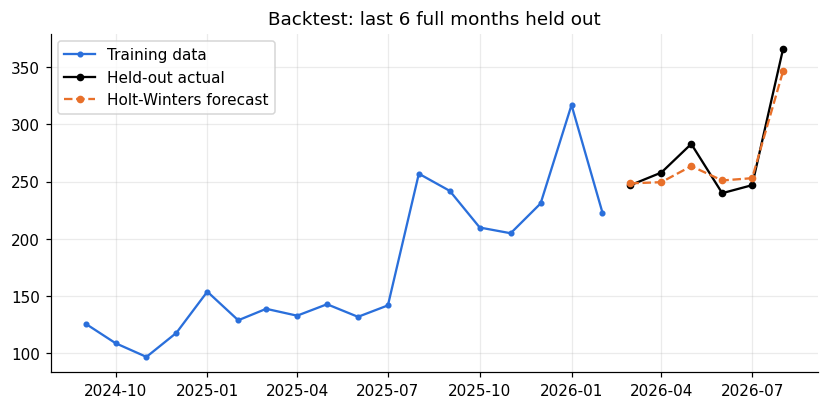

Holt-Winters average error: 3.9%
Naive baseline error:       16.7%


In [11]:
def holt_winters(series, horizon):
    fit = ExponentialSmoothing(series, trend="add", seasonal="add", seasonal_periods=12,
                               initialization_method="estimated").fit()
    return fit.forecast(horizon)

series = monthly[monthly.index >= monthly[monthly > 0].index.min()]
h = 6
train, test = series.iloc[:-h], series.iloc[-h:]
pred = holt_winters(train, h)
naive = pd.Series(train.iloc[-1], index=test.index)
mape = lambda a, f: (abs(a - f) / a).mean() * 100

fig, ax = plt.subplots()
ax.plot(train.index[-18:], train.values[-18:], color=BLUE, marker="o", ms=3, label="Training data")
ax.plot(test.index, test.values, color="black", marker="o", ms=4, label="Held-out actual")
ax.plot(test.index, pred.values, color=ORANGE, marker="o", ms=4, ls="--", label="Holt-Winters forecast")
ax.set_title("Backtest: last 6 full months held out")
ax.legend()
plt.show()
print("Holt-Winters average error: %.1f%%" % mape(test, pred))
print("Naive baseline error:       %.1f%%" % mape(test, naive))

Now the same model on all the data, forecasting the four months from September to December 2026.

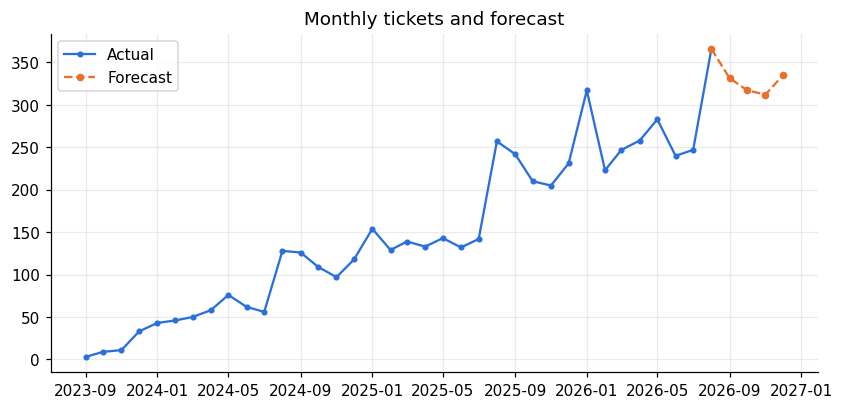

2026-09    331
2026-10    317
2026-11    312
2026-12    335


In [12]:
future = holt_winters(series, 4)

fig, ax = plt.subplots()
ax.plot(series.index, series.values, color=BLUE, marker="o", ms=3, label="Actual")
line = pd.concat([series.iloc[[-1]], future])
ax.plot(line.index, line.values, color=ORANGE, marker="o", ms=4, ls="--", label="Forecast")
ax.set_title("Monthly tickets and forecast")
ax.legend()
plt.show()
print(future.round(0).astype(int).rename(lambda d: d.strftime("%Y-%m")).to_string())

**Takeaway:** on the holdout the model misses by about 4% on average, against about 17% for the naive baseline,
so it is genuinely capturing structure. One caveat: this is a single backtest window on synthetic data with
clean seasonality; real ticket data would be noisier.

## 7. Auto-tagging tickets from their text

Can a model assign the category from the description alone? TF-IDF turns each description into word and
word-pair weights, and a logistic regression learns which of them point to which category. It is scored on 25%
of tickets it never saw.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    tickets.description, tickets.category, test_size=0.25, random_state=42, stratify=tickets.category)

model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
    ("clf", SGDClassifier(loss="log_loss", random_state=42)),
]).fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

             Battery       0.96      0.81      0.88       151
     Driver/Firmware       0.96      0.86      0.91       223
    Hardware Failure       0.80      0.91      0.85       226
Network/Connectivity       0.90      0.85      0.87       240
               Other       0.98      0.88      0.93       102
       Print Quality       0.96      0.86      0.91       178
         Software/OS       0.77      0.94      0.85       257

            accuracy                           0.88      1377
           macro avg       0.90      0.87      0.89      1377
        weighted avg       0.89      0.88      0.88      1377



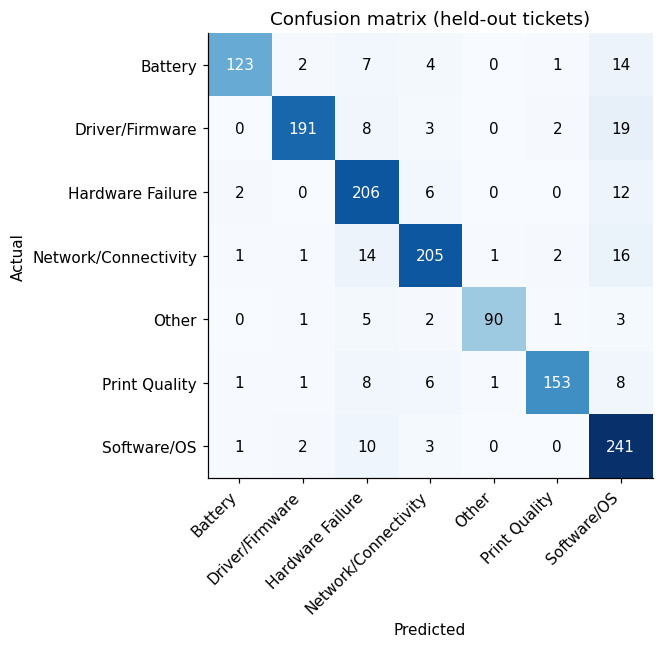

In [14]:
labels = sorted(tickets.category.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion matrix (held-out tickets)")
ax.grid(False)
plt.tight_layout()
plt.show()

In [15]:
# The generator swaps in one of these generic sentences for about 12% of tickets.
VAGUE = {
    "Device is not working properly, please assist.", "Having an issue since yesterday, need help.",
    "Something is wrong with my device, urgent.", "Problem reported by user, details unclear.",
    "Not behaving as expected, requesting support.", "Issue persists after restart, please advise.",
}
is_vague = X_test.isin(VAGUE)
wrong = y_pred != y_test.values
print("Distinct descriptions across %d tickets: %d" % (len(tickets), tickets.description.nunique()))
print("Accuracy on specific descriptions: %.1f%%" % ((~wrong[~is_vague.values]).mean() * 100))
print("Accuracy on vague descriptions:    %.1f%%" % ((~wrong[is_vague.values]).mean() * 100))
print("Share of all errors that are vague tickets: %.0f%%" % (is_vague.values[wrong].mean() * 100))

Distinct descriptions across 5505 tickets: 65
Accuracy on specific descriptions: 95.9%
Accuracy on vague descriptions:    19.9%
Share of all errors that are vague tickets: 70%


**Takeaway and caveat:** about 88% accuracy across seven categories, and 96% when the description says
something specific. The errors come mostly (70%) from vague tickets such as "not working properly", which carry
no signal for any model; that is also true of real support data. The overall number describes this synthetic
text, not real tickets: descriptions come from a small set of templates, with about 12% made vague and 4%
mislabeled to keep the task from being trivial. On real tickets the same pipeline would need real text to
train on.

## Summary

| Finding | Evidence | Recommendation |
|---|---|---|
| A bad EliteBook 840 batch | Q1 2025 cohort at 1.21 battery tickets per device vs. 0.17-0.44 for other quarters through 2025 | Proactively replace batteries for that cohort |
| Demand is seasonal | Aug 1.35x, Sep 1.22x, Jan 1.27x, Jun-Jul 0.75x vs. trend | Staff for the peaks, not the average |
| Severity drives resolution time | Critical about 69 hours vs. Low 4.6; flat across category within a severity | Set SLAs by severity, fast-path Critical |
| Product matters more than region | 1.31-2.24 tickets/device by model vs. 1.78-1.96 by region | Use per-model rates for reliability targets |
| The forecast is usable | About 4% backtest error vs. about 17% for a naive baseline | Plan capacity from the forecast |